<a href="https://colab.research.google.com/github/trishausirikapalli-del/growfinix/blob/main/Task1_Titatanic_Dataset_Survival_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Data Overview ---
Shape: (891, 15)

Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipykernel_8902/58057813.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, palette='viridis')
/tmp/ipykernel_8902/58057813.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pclass', y='survived', data=df, palette='magma')
/tmp/ipykernel_8902/58057813.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='survived', data=df, palette='coolwarm')


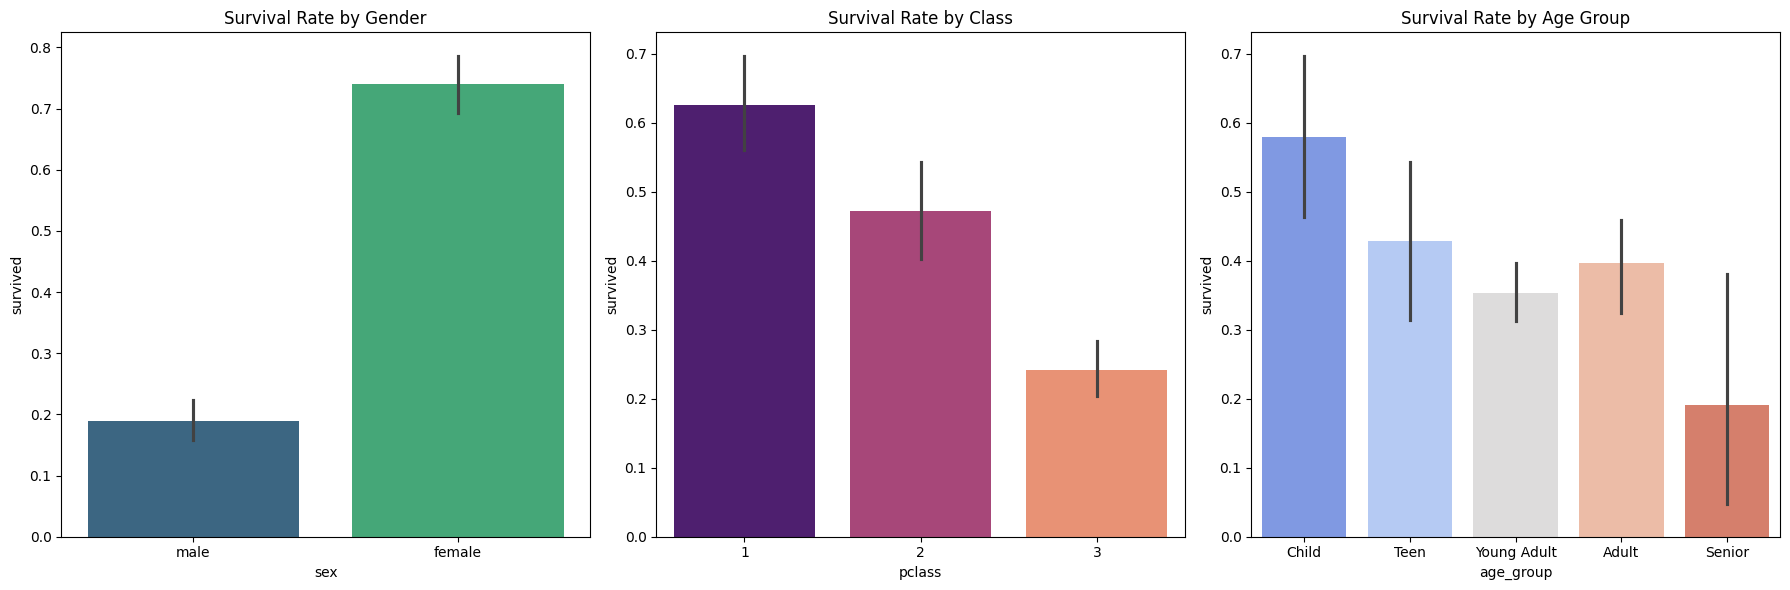

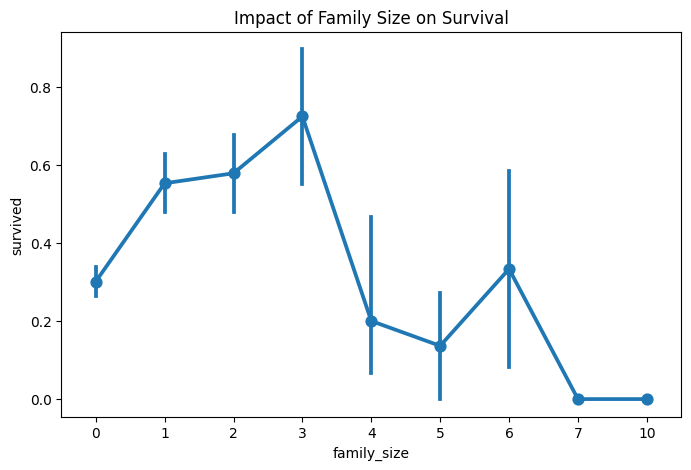


--- Survival Rate Pivot Table ---
pclass         1         2         3
sex                                 
female  0.967391  0.921053  0.500000
male    0.368852  0.157407  0.135447


/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)



--- Final Conclusions ---
1. Gender: Female survival rate is significantly higher (around 74%) compared to males (around 18%).
2. Class: Pclass 1 had the highest survival priority, while Pclass 3 had the lowest.
3. Age: Children (0-12) had a better survival rate than other age groups.
4. Family: People with small families (1-3 members) survived better than those alone or in very large families.

Task 1 Completed! Files saved: 'final_cleaned_titanic_data.csv', 'survival_analysis_plots.png', 'family_size_analysis.png'


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px  #  for Bonus: Interactive plots

# 1. Load Titanic dataset
df = sns.load_dataset('titanic')

# 2. Check data types, missing values, and shape
print("--- Data Overview ---")
print(f"Shape: {df.shape}")
print("\nMissing Values:\n", df.isnull().sum())

# 3. Fill or drop missing data
df['age'] = df['age'].fillna(df['age'].median())
df.drop(columns=['deck', 'embark_town', 'alive', 'who', 'adult_male'], inplace=True) # Extra redundancy removed
df.dropna(subset=['embarked'], inplace=True)

# 4. Convert 'Sex' and 'Embarked' into numeric codes
df['sex_code'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked_code'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 5. Create plots for survival vs gender/class/age group
plt.figure(figsize=(18, 6))

# Plot A: Gender vs Survival
plt.subplot(1, 3, 1)
sns.barplot(x='sex', y='survived', data=df, palette='viridis')
plt.title('Survival Rate by Gender')

# Plot B: Class vs Survival
plt.subplot(1, 3, 2)
sns.barplot(x='pclass', y='survived', data=df, palette='magma')
plt.title('Survival Rate by Class')

# Plot C: Age Group vs Survival
plt.subplot(1, 3, 3)
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
sns.barplot(x='age_group', y='survived', data=df, palette='coolwarm')
plt.title('Survival Rate by Age Group')

plt.tight_layout()
plt.savefig('survival_analysis_plots.png') # 10. Save charts as images
plt.show()

# 6. Family size vs Survival (family_size = siblings + parents)
df['family_size'] = df['sibsp'] + df['parch']
plt.figure(figsize=(8, 5))
sns.pointplot(x='family_size', y='survived', data=df)
plt.title('Impact of Family Size on Survival')
plt.savefig('family_size_analysis.png')
plt.show()

# 7. Pivot Table for Deeper Insights
pivot_report = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')
print("\n--- Survival Rate Pivot Table ---")
print(pivot_report)

# 8. Bonus: Interactive Plot using Plotly
#  it will on browser when u hover it.
fig = px.sunburst(df, path=['pclass', 'sex', 'age_group'], values='survived',
                  title="Interactive Survival Breakdown (Class -> Gender -> Age)")
fig.show()

# 9. Conclusions
print("\n--- Final Conclusions ---")
print("1. Gender: Female survival rate is significantly higher (around 74%) compared to males (around 18%).")
print("2. Class: Pclass 1 had the highest survival priority, while Pclass 3 had the lowest.")
print("3. Age: Children (0-12) had a better survival rate than other age groups.")
print("4. Family: People with small families (1-3 members) survived better than those alone or in very large families.")

# 10. Export cleaned dataset
df.to_csv('final_cleaned_titanic_data.csv', index=False)
print("\nTask 1 Completed! Files saved: 'final_cleaned_titanic_data.csv', 'survival_analysis_plots.png', 'family_size_analysis.png'")